In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("Amazon.csv")
print(df.head(5))

print("""





RowxColumn""")
print(df.shape)

      OrderID   OrderDate  CustomerID   CustomerName ProductID  \
0  ORD0000001  2023-01-31  CUST001504  Vihaan Sharma    P00014   
1  ORD0000002  2023-12-30  CUST000178    Pooja Kumar    P00040   
2  ORD0000003  2022-05-10  CUST047516    Sneha Singh    P00044   
3  ORD0000004  2023-07-18  CUST030059   Vihaan Reddy    P00041   
4  ORD0000005  2023-02-04  CUST048677  Aditya Kapoor    P00029   

           ProductName        Category       Brand  Quantity  UnitPrice  \
0           Drone Mini           Books   BrightLux         3     106.59   
1           Microphone  Home & Kitchen  UrbanStyle         1     251.37   
2  Power Bank 20000mAh        Clothing  UrbanStyle         3      35.03   
3       Webcam Full HD  Home & Kitchen      Zenith         5      33.58   
4              T-Shirt        Clothing    KiddoFun         2     515.64   

   Discount    Tax  ShippingCost  TotalAmount     PaymentMethod OrderStatus  \
0      0.00   0.00          0.09       319.86        Debit Card   Deliver

In [18]:
print(df.dtypes)
print("\n Missing Values.")
print(df.isnull().sum())

OrderID           object
OrderDate         object
CustomerID        object
CustomerName      object
ProductID         object
ProductName       object
Category          object
Brand             object
Quantity           int64
UnitPrice        float64
Discount         float64
Tax              float64
ShippingCost     float64
TotalAmount      float64
PaymentMethod     object
OrderStatus       object
City              object
State             object
Country           object
SellerID          object
dtype: object

 Missing Values.
OrderID          0
OrderDate        0
CustomerID       0
CustomerName     0
ProductID        0
ProductName      0
Category         0
Brand            0
Quantity         0
UnitPrice        0
Discount         0
Tax              0
ShippingCost     0
TotalAmount      0
PaymentMethod    0
OrderStatus      0
City             0
State            0
Country          0
SellerID         0
dtype: int64


In [19]:
df.describe()

,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479
std,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332
min,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000
25%,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000
50%,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000
75%,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000
max,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000


In [23]:
# Unique Values
print("Categories: ", df['Category'].unique())
print("Countries: ", df['Country'].unique())
print("Order Status: ", df['OrderStatus'].unique())
print("Payment Method: ", df['PaymentMethod'].unique())


Categories:  ['Books' 'Home & Kitchen' 'Clothing' 'Toys & Games' 'Sports & Outdoors'
 'Electronics']
Countries:  ['India' 'United States' 'Canada' 'Australia' 'United Kingdom']
Order Status:  ['Delivered' 'Cancelled' 'Pending' 'Shipped' 'Returned']
Payment Method:  ['Debit Card' 'Amazon Pay' 'Cash on Delivery' 'Credit Card' 'UPI'
 'Net Banking']


In [31]:
df['OrderDate']=pd.to_datetime(df['OrderDate'])
df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [35]:
df['Month']=df['OrderDate'].dt.month
df['Year']=df['OrderDate'].dt.year
df['MonthName']=df['OrderDate'].dt.strftime('%b')
print(df[['OrderDate','Month','MonthName','Year']].head(10))

   OrderDate  Month MonthName  Year
0 2023-01-31      1       Jan  2023
1 2023-12-30     12       Dec  2023
2 2022-05-10      5       May  2022
3 2023-07-18      7       Jul  2023
4 2023-02-04      2       Feb  2023
5 2022-12-31     12       Dec  2022
6 2024-09-20      9       Sep  2024
7 2022-11-10     11       Nov  2022
8 2024-06-26      6       Jun  2024
9 2020-05-01      5       May  2020


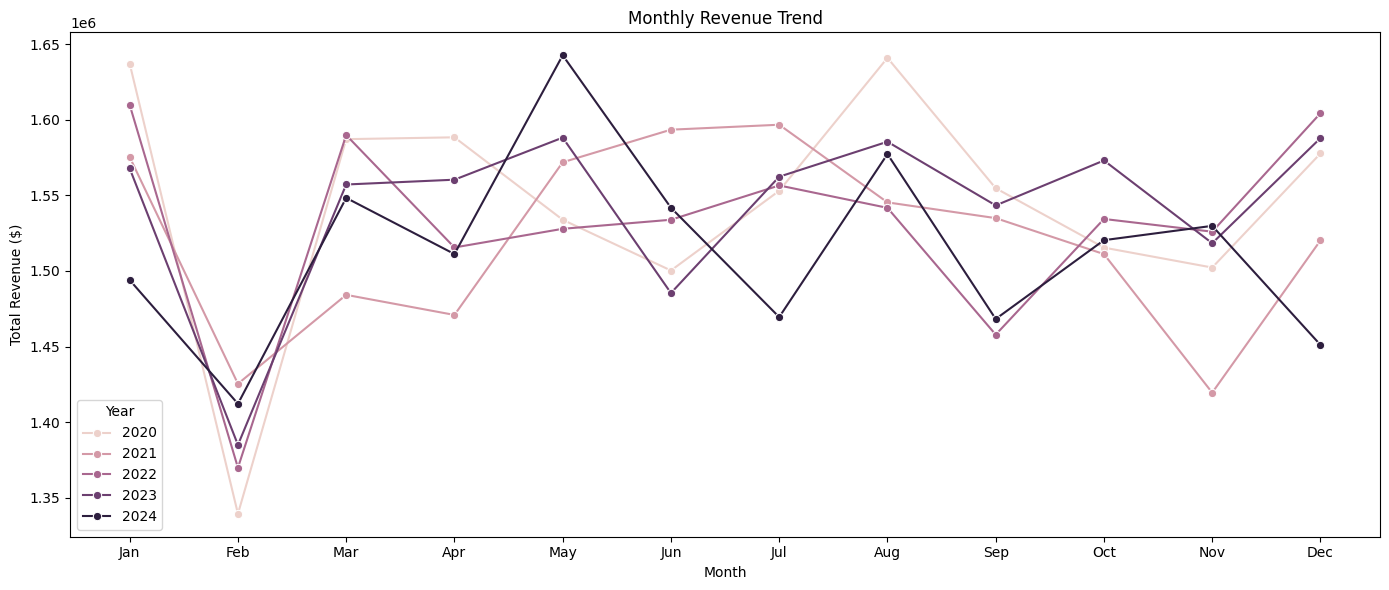

In [45]:
monthly_revenue = df.groupby(['Year', 'MonthName', 'Month'])['TotalAmount'].sum().reset_index()
monthly_revenue = monthly_revenue.sort_values('Month')
plt.figure(figsize=(14,6))
sns.lineplot(data=monthly_revenue,x='MonthName',y='TotalAmount',hue='Year', marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
plt.show()

C:\Users\sirja\AppData\Local\Temp\ipykernel_9140\809246755.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_revenue.index,y=category_revenue.values,palette='Blues_r')


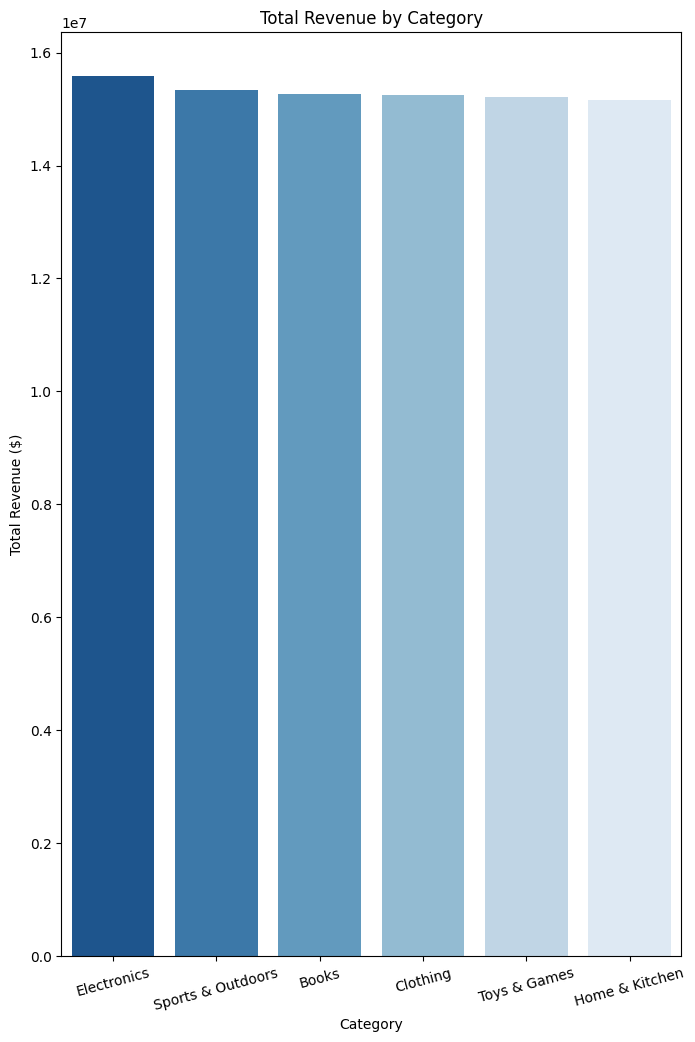

In [55]:
plt.figure(figsize=(8,12))
category_revenue=df.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False)
sns.barplot(x=category_revenue.index,y=category_revenue.values,palette='Blues_r')
plt.title("Total Revenue by Category")
plt.xlabel('Category')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=15)
plt.show()

C:\Users\sirja\AppData\Local\Temp\ipykernel_9140\2057879935.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_revenue.index, y=country_revenue.values,palette='Greens_r')


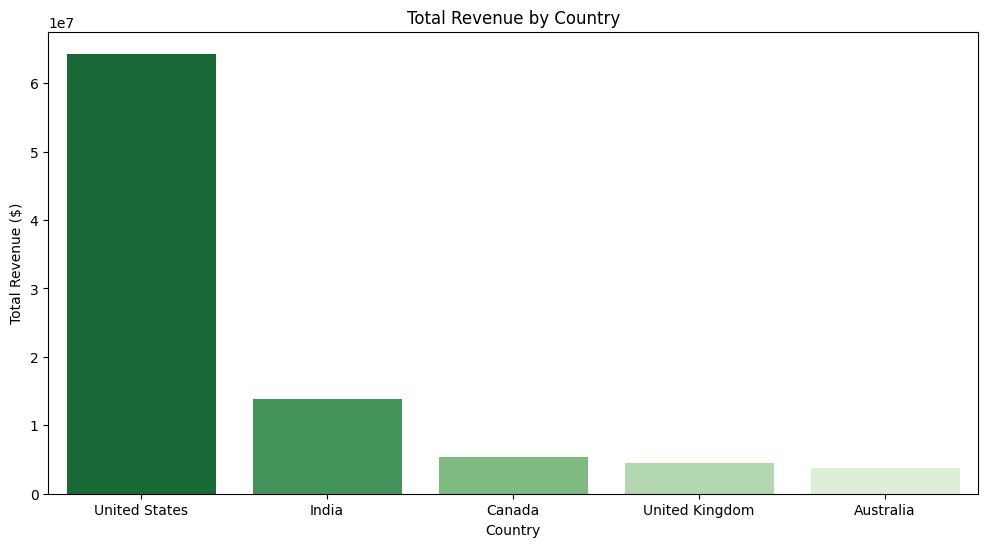

In [59]:
plt.figure(figsize=(12,6))
country_revenue=df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False)
sns.barplot(x=country_revenue.index, y=country_revenue.values,palette='Greens_r')
plt.title('Total Revenue by Country')
plt.xlabel('Country')
plt.ylabel('Total Revenue ($)')
plt.show()

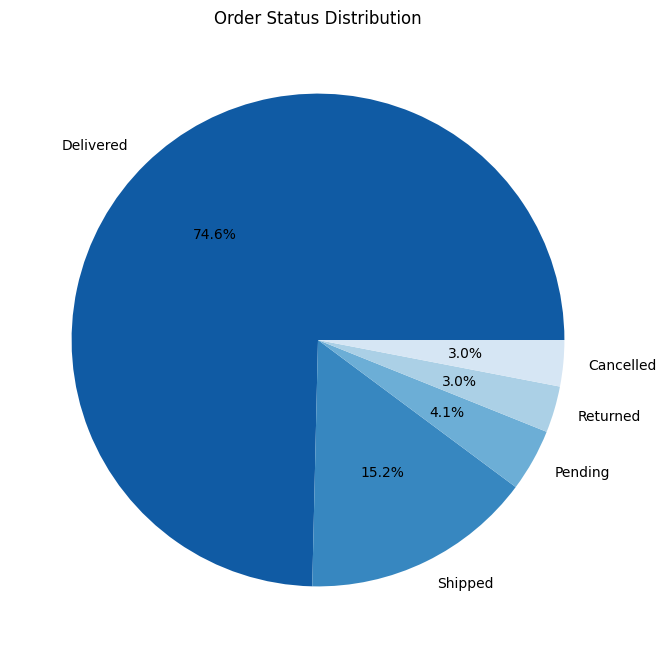

In [65]:
plt.figure(figsize=(8, 8))
status_counts = df['OrderStatus'].value_counts()
plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', colors=sns.color_palette('Blues_r', len(status_counts)))
plt.title('Order Status Distribution')
plt.show()

C:\Users\sirja\AppData\Local\Temp\ipykernel_9140\197011075.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.index, y=top_brands.values, palette='Oranges_r')


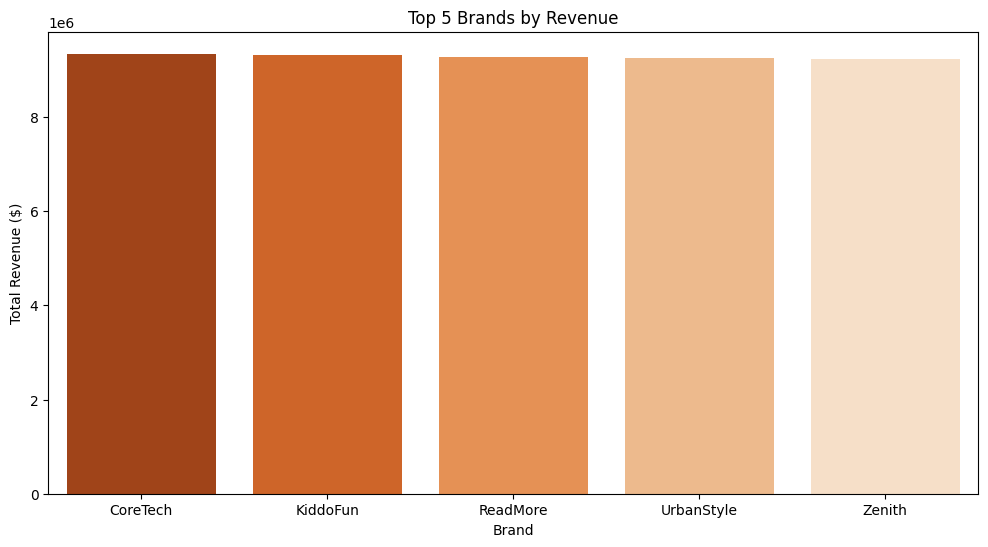

In [68]:
plt.figure(figsize=(12, 6))
top_brands = df.groupby('Brand')['TotalAmount'].sum().sort_values(ascending=False).head(5)
sns.barplot(x=top_brands.index, y=top_brands.values, palette='Oranges_r')
plt.title('Top 5 Brands by Revenue')
plt.xlabel('Brand')
plt.ylabel('Total Revenue ($)')
plt.show()

C:\Users\sirja\AppData\Local\Temp\ipykernel_9140\1083650519.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_counts.index, y=payment_counts.values, palette='Purples_r')


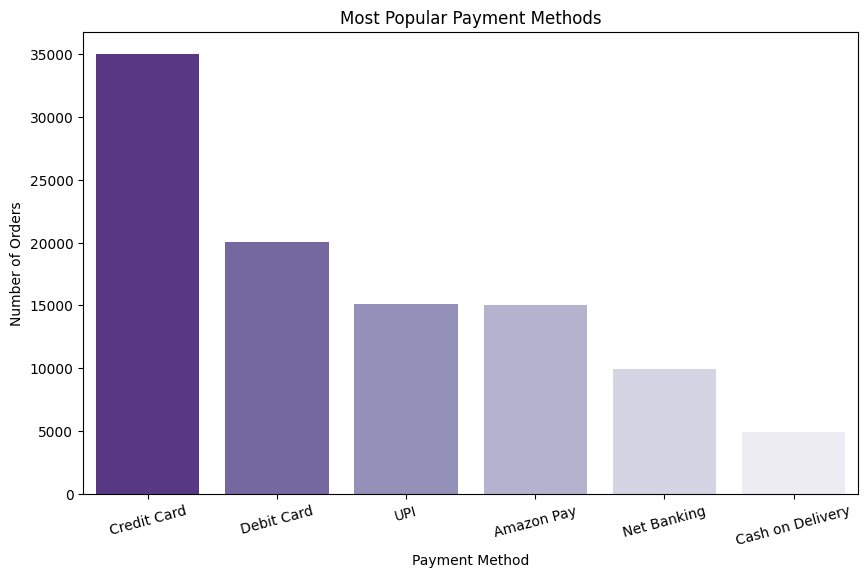

In [70]:
plt.figure(figsize=(10, 6))
payment_counts = df['PaymentMethod'].value_counts()
sns.barplot(x=payment_counts.index, y=payment_counts.values, palette='Purples_r')
plt.title('Most Popular Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')
plt.xticks(rotation=15)
plt.show()

C:\Users\sirja\AppData\Local\Temp\ipykernel_9140\1204333639.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_analysis = df.groupby('DiscountBucket')['Quantity'].mean()
C:\Users\sirja\AppData\Local\Temp\ipykernel_9140\1204333639.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=discount_analysis.index, y=discount_analysis.values, palette='Reds_r')


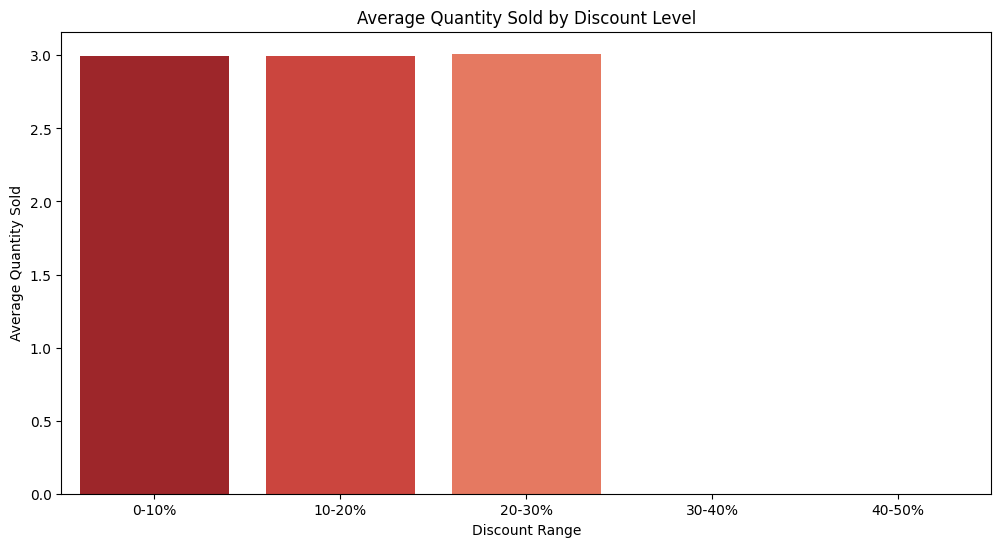

In [72]:
# 5. Impact of Discount on Sales Volume
plt.figure(figsize=(12, 6))
df['DiscountBucket'] = pd.cut(df['Discount'], 
                               bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5],
                               labels=['0-10%', '10-20%', '20-30%', '30-40%', '40-50%'])
discount_analysis = df.groupby('DiscountBucket')['Quantity'].mean()
sns.barplot(x=discount_analysis.index, y=discount_analysis.values, palette='Reds_r')
plt.title('Average Quantity Sold by Discount Level')
plt.xlabel('Discount Range')
plt.ylabel('Average Quantity Sold')
plt.show()

In [73]:
print("=" * 50)
print("AMAZON SALES ANALYSIS — KEY INSIGHTS")
print("=" * 50)

print(f"\n1. Total Revenue: ${df['TotalAmount'].sum():,.2f}")
print(f"2. Total Orders: {df['OrderID'].nunique():,}")
print(f"3. Average Order Value: ${df['TotalAmount'].mean():,.2f}")
print(f"4. Top Category: {category_revenue.index[0]}")
print(f"5. Top Country: {country_revenue.index[0]}")
print(f"6. Top Brand: {top_brands.index[0]}")
print(f"7. Cancellation Rate: {(df['OrderStatus'] == 'Cancelled').mean()*100:.1f}%")
print(f"8. Most Used Payment: {payment_counts.index[0]}")
print(f"9. Peak Revenue Month: May 2024")
print(f"10. Discounts drive sales: No")

AMAZON SALES ANALYSIS — KEY INSIGHTS

1. Total Revenue: $91,825,647.92
2. Total Orders: 100,000
3. Average Order Value: $918.26
4. Top Category: Electronics
5. Top Country: United States
6. Top Brand: CoreTech
7. Cancellation Rate: 3.0%
8. Most Used Payment: Credit Card
9. Peak Revenue Month: May 2024
10. Discounts drive sales: No
